# Predicting NYC Taxi Trip Durations with LightGBM

## Overview

This project aims to use LightGBM to predict the duration (in seconds) of taxi trips in NYC based on individual trip attributes, using the dataset from https://www.kaggle.com/competitions/nyc-taxi-trip-duration/data. 

## Dataset
The dataset includes the following features: 

- drop-off and pick up longitude, latitude and datetime
- number of passenger 

## Evaluation metric 
- Root Mean Squared Log Error (RMSLE) to evaluate models based on relative errors between the predicted and actual trip duartion. 

## Why LightGBM?
LightGBM is suited for this task because of its histogram-based decision tree construction and leaf-wise growth strategy. It allows the processing of millions of rows in seconds, inherently handle mixed continuous and categorical data features, and effortlessly map out complex, non-linear geographical correlations without collapsing under heavy memory usage.

## Data & Import

In [1]:
# Libraries
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import joblib


# Set seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [3]:
# Read the data files 

# The training set (contains 1458644 trip records)
df = pd.read_csv("train.csv")
print("Shape of train df:", df.shape)
df.head()


Shape of train df: (1458644, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


## Data Cleaning

In [4]:
# Distribution of the trip_duration
# More than 75% of trips are under 1 hour
df['trip_duration'].describe().apply(lambda x: format(x, '.2f'))

count    1458644.00
mean         959.49
std         5237.43
min            1.00
25%          397.00
50%          662.00
75%         1075.00
max      3526282.00
Name: trip_duration, dtype: str

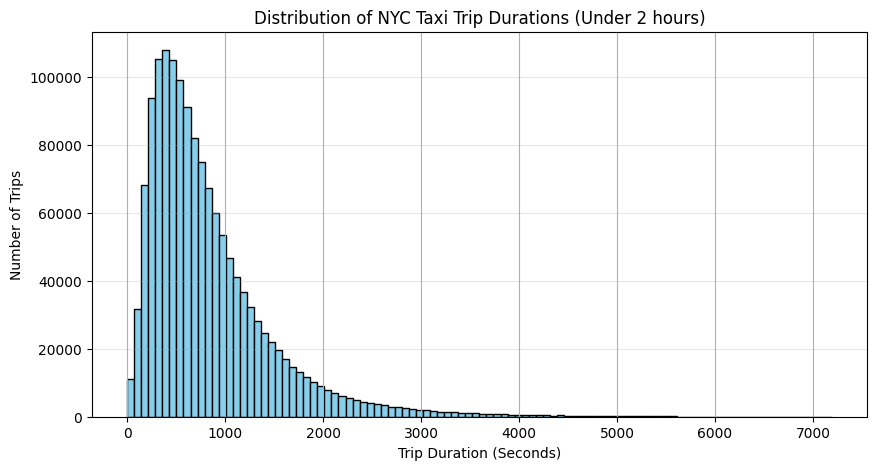

In [5]:
# Plot a histogram of trips 
plt.figure(figsize=(10, 5))
df[df['trip_duration']<7200]['trip_duration'].hist(bins=100, color='skyblue', edgecolor='black')

plt.title('Distribution of NYC Taxi Trip Durations (Under 2 hours)')
plt.xlabel('Trip Duration (Seconds)')
plt.ylabel('Number of Trips')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [6]:
# Remove the outliers - Drop trips that last lpnger than 24 hours or shorter than 1 minute
df = df[(df['trip_duration'] > 60) & (df['trip_duration'] < 86400)].reset_index(drop=True)
print(df.shape)

(1449863, 11)


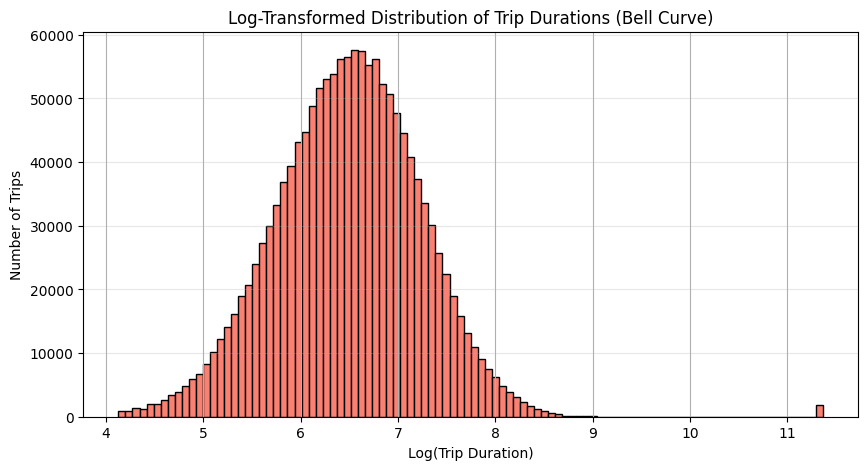

In [7]:
# Taking the log1p (log(1 + x)) stabilises variance and helps LightGBM converge faster
df['log_trip_duration'] = np.log1p(df['trip_duration'])

# Plot the log-transformed distribution (creates a beautiful normal bell-curve)
plt.figure(figsize=(10, 5))
df['log_trip_duration'].hist(bins=100, color='salmon', edgecolor='black')

plt.title('Log-Transformed Distribution of Trip Durations (Bell Curve)')
plt.xlabel('Log(Trip Duration)')
plt.ylabel('Number of Trips')
plt.grid(axis='y', alpha=0.3)
plt.show()

## Feature Engineering

Compute new features such as day of week, month and hour of the pick up and distance

In [8]:
# Add 
def engineer_features(data):
    df_feat = data.copy()
    
    # Time-Based Features
    df_feat['pickup_datetime'] = pd.to_datetime(df_feat['pickup_datetime'])
    df_feat['pickup_hour'] = df_feat['pickup_datetime'].dt.hour
    df_feat['pickup_day_of_week'] = df_feat['pickup_datetime'].dt.dayofweek
    df_feat['pickup_month'] = df_feat['pickup_datetime'].dt.month
    df_feat['is_weekend'] = df_feat['pickup_day_of_week'].isin([5, 6]).astype(int)
    
    # Geospatial Features (Manhattan Distance Approximation)
    # Calculates absolute lat/long differences as rough distance proxies
    df_feat['lat_diff'] = (df_feat['dropoff_latitude'] - df_feat['pickup_latitude']).abs()
    df_feat['lon_diff'] = (df_feat['dropoff_longitude'] - df_feat['pickup_longitude']).abs()
    df_feat['manhattan_dist'] = df_feat['lat_diff'] + df_feat['lon_diff']                     # The distance along the two perpendicular sides
    
    # Native Categorical Handling
    # Store_and_fwd_flag ('Y'/'N') and Vendor ID should be explicit categories
    df_feat['store_and_fwd_flag'] = df_feat['store_and_fwd_flag'].astype('category')
    df_feat['vendor_id'] = df_feat['vendor_id'].astype('category')
    
    return df_feat

df_engineered = engineer_features(df)

In [9]:
df_engineered.info()

<class 'pandas.DataFrame'>
RangeIndex: 1449863 entries, 0 to 1449862
Data columns (total 19 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1449863 non-null  str           
 1   vendor_id           1449863 non-null  category      
 2   pickup_datetime     1449863 non-null  datetime64[us]
 3   dropoff_datetime    1449863 non-null  str           
 4   passenger_count     1449863 non-null  int64         
 5   pickup_longitude    1449863 non-null  float64       
 6   pickup_latitude     1449863 non-null  float64       
 7   dropoff_longitude   1449863 non-null  float64       
 8   dropoff_latitude    1449863 non-null  float64       
 9   store_and_fwd_flag  1449863 non-null  category      
 10  trip_duration       1449863 non-null  int64         
 11  log_trip_duration   1449863 non-null  float64       
 12  pickup_hour         1449863 non-null  int32         
 13  pickup_day_of_week  144

In [10]:
df_engineered['manhattan_dist'].describe().apply(lambda x: format(x, '.2f'))

count    1449863.00
mean           0.05
std            0.06
min            0.00
25%            0.02
50%            0.03
75%            0.05
max           12.91
Name: manhattan_dist, dtype: str

# Prepare train/ test split

In [11]:
# Define features and target
features = [
    'vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
    'pickup_hour', 'pickup_day_of_week', 'pickup_month', 'is_weekend',
    'lat_diff', 'lon_diff', 'manhattan_dist'
]

target = 'log_trip_duration'

X = df_engineered[features]
y = df_engineered[target]

# Train/Validation Split (80/20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

print(f"Training features shape: {X_train.shape}")
print(f"Validation features shape: {X_val.shape}")

Training features shape: (1159890, 14)
Validation features shape: (289973, 14)


# 5 Fold Cross Validation

In [12]:
# Define optimized hyperparameters for tabular regression
lgb_params = {
    'n_estimators': 1500,       # Maximum number of trees
    'learning_rate': 0.05,      # Step size shrinkage
    'num_leaves': 63,           # Main parameter controlling tree complexity
    'max_depth': -1,            # Unconstrained depth (controlled by num_leaves)
    'subsample': 0.8,           # Row bagging fraction
    'colsample_bytree': 0.8,    # Feature bagging fraction
    'random_state': RANDOM_SEED
}

In [14]:
from sklearn.model_selection import KFold

# 1. Define features and target (using the engineered dataframe from before)
X = df_engineered[features]
y = df_engineered[target]

# 2. Set up K-Fold generator
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics for each fold
fold_rmsle_scores = []
fold_mae_scores = []

print("Starting 5-Fold Cross-Validation...\n")

# 3. Loop through each fold
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"--- Training Fold {fold + 1}/{kf.n_splits} ---")
    
    # Split the data
    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
    
    # Initialize a fresh LightGBM model for this fold
    model_cv = lgb.LGBMRegressor(**lgb_params)
    
    # Train the model
    model_cv.fit(
        X_train_cv, y_train_cv,
        eval_set=[(X_val_cv, y_val_cv)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)] 
    )
    
    # Predict on the validation fold
    y_pred_log_cv = model_cv.predict(X_val_cv)
    
    # Convert back to seconds for MAE calculation
    y_val_seconds_cv = np.expm1(y_val_cv)
    y_pred_seconds_cv = np.clip(np.expm1(y_pred_log_cv), 0, None)
    
    # Calculate metrics for this specific fold
    rmsle = np.sqrt(mean_squared_error(y_val_cv, y_pred_log_cv))
    mae = mean_absolute_error(y_val_seconds_cv, y_pred_seconds_cv)
    
    fold_rmsle_scores.append(rmsle)
    fold_mae_scores.append(mae)
    
    print(f"Fold {fold + 1} RMSLE: {rmsle:.4f} | MAE: {mae / 60:.2f} minutes")

print("\n=== Final Cross-Validation Results ===")
print(f"Mean RMSLE: {np.mean(fold_rmsle_scores):.4f} (+/- {np.std(fold_rmsle_scores):.4f})")
print(f"Mean MAE: {np.mean(fold_mae_scores) / 60:.2f} minutes")

Starting 5-Fold Cross-Validation...

--- Training Fold 1/5 ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007590 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1837
[LightGBM] [Info] Number of data points in the train set: 1159890, number of used features: 14
[LightGBM] [Info] Start training from score 6.487758
Fold 1 RMSLE: 0.3632 | MAE: 4.91 minutes
--- Training Fold 2/5 ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007417 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 1159890, number of used features: 14
[LightGBM] [Info] Start training from score 6.487259
Fold 2 RMSLE: 0.3614 | MAE: 4.82 minutes
--- Training 

# Train final model

In [13]:
# Initialize model
model = lgb.LGBMRegressor(**lgb_params)

# Train with early stopping to stop adding trees when validation error plateaus
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True)]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008184 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1837
[LightGBM] [Info] Number of data points in the train set: 1159890, number of used features: 14
[LightGBM] [Info] Start training from score 6.487758
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1500]	valid_0's l2: 0.132108


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=1500,
              num_leaves=63, random_state=42, subsample=0.8)

In [14]:
# 1. Predict on validation set (in log scale)
y_pred_log = model.predict(X_val)

# 2. Convert back to original scale (seconds)
y_val_seconds = np.expm1(y_val)
y_pred_seconds = np.expm1(y_pred_log)

# 3. Handle any accidental negative predictions from back-transformation
y_pred_seconds = np.clip(y_pred_seconds, 0, None)

# --- Compute Metrics ---
rmsle = np.sqrt(mean_squared_error(y_val, y_pred_log)) # Kaggle evaluation metric for this competition
mae_seconds = mean_absolute_error(y_val_seconds, y_pred_seconds)
r2 = r2_score(y_val_seconds, y_pred_seconds)

print("\n=== Validation Performance ===")
print(f"Root Mean Squared Log Error (RMSLE): {rmsle:.4f}")
print(f"Mean Absolute Error: {mae_seconds / 60:.2f} minutes")
print(f"R² Score: {r2:.4f}")


=== Validation Performance ===
Root Mean Squared Log Error (RMSLE): 0.3635
Mean Absolute Error: 4.92 minutes
R² Score: 0.0335


# Feature importance

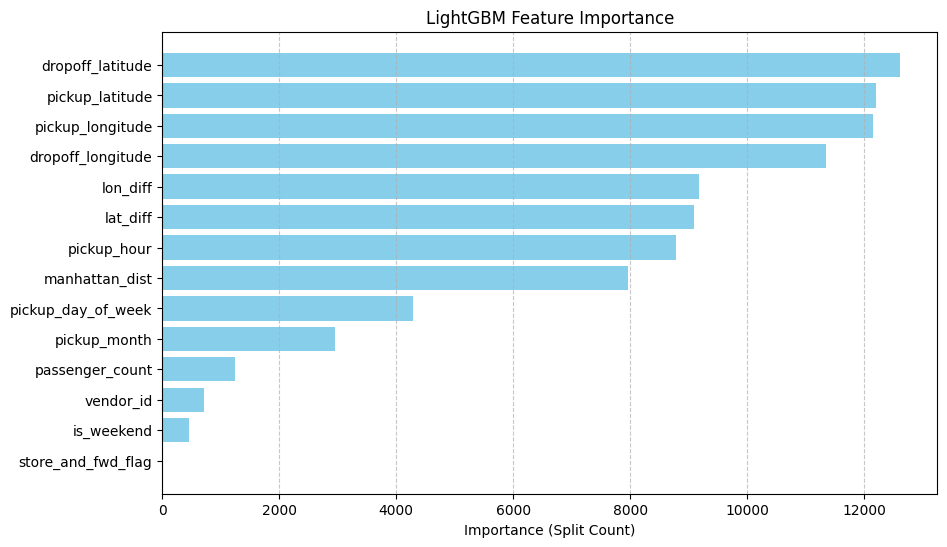

In [16]:
# feature importances from the trained model
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'], importance['Importance'], color='skyblue')
plt.xlabel('Importance (Split Count)')
plt.title('LightGBM Feature Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Save Model

In [17]:
joblib.dump(model, "nyc_taxi_lightGBM.pkl")

['nyc_taxi_lightGBM.pkl']

In [18]:
joblib.dump(features, "feature_names.pkl")

['feature_names.pkl']

# Conclusion

#### Model Performance Summary:
- Cross-Validated RMSLE: 0.364
- Average Prediction Error (MAE): 4.81 minutes
- Model Stability: The 0.0013 standard deviation across our 5-fold cross-validation proves that the model does not overfit to specific random subsets of data and will generalise to unseen real-world taxi trips.


#### Key Features:
- pickup and drop off long and lat
- lat/long differences
- pickup hour
- manhattan distance


--> This reveals that while our engineered manhattan_dist provides a strong global baseline for distance, the raw latitude and longitude coordinates remain the most critical features for the model. This indicates that LightGBM is successfully utilising the raw coordinates to map out highly localised spatial patterns which influence trip duration far more than raw distance alone.

### Next steps:
- High-Fidelity Distance Metrics (Haversine & OSRM): calculating the Haversine Distance provides a more precise physical distance.

- Spatial Clustering (K-Means or H3): Use K-Means Clustering or Uber's H3 spatial index to bucket the latitudes and longitudes into specific categorical neighborhood zones. LightGBM can natively use these categorical zones to discover complex neighborhood-to-neighborhood transit patterns.

- Add weather context to capture averge traffic velocities during different weather events.